<a href="https://colab.research.google.com/github/22ivanseijo-creator/MyClassRepository/blob/main/Actualizaci%C3%B3n2_C%C3%93DIGO_PRINCIPAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
### ACTUALIZACIÓN 1

In [61]:
# IMPORTACIÓN DE LIBRERÍAS

In [62]:
# A continuación instalamos xgboost que será nuestro algoritmo de boosting,
# también instalamos unidecode pues más adelante nos darán problemas los
# nombres y con esta librería lo podremos solucionar.

In [63]:
!pip install scikit-learn xgboost unidecode --quiet

In [64]:
# Ahora importamos poco a poco todas las librerías que creamos necesarias
# para la creación del modelo.

In [187]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
from unidecode import unidecode

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
import joblib
from google.colab import files

warnings.filterwarnings('ignore')

In [66]:
# CARGA DE DATOS

In [67]:
# Cargamos los datasets
# 1º el de la acb y 2º el de la nba

In [68]:
df_acb = pd.read_csv('/content/drive/MyDrive/ESTUDIOS/Máster SBL/TFM/CARGA DATOS/acb_datos_jugadores_1983_2022.csv')
# Usamos low_memory = False pues tras ver estos datasets, en el de la NBA, hay
# datos mixtos y estos pueden crear warnings, con esa línea evitamos que lo haga.
df_nba = pd.read_csv('/content/drive/MyDrive/ESTUDIOS/Máster SBL/TFM/CARGA DATOS/PlayerStatisticsExtended.csv', low_memory=False)

In [69]:
# Ahora vemos los dos datasets

In [70]:
# Dataset de la acb
df_acb

,Nombre,Equipo,Posición,Altura,Lugar de nacimiento,Fecha de nacimiento,Nacionalidad,Temporada,Número de partidos,Total minutos jugados,...,Número de balones recuperados,Número de tapones realizados,Numero de tapones recibidos,Número de mates,Número de faltas realizadas,Número de faltas recibidas,+/-,Valoración,Partidos ganados,Partidos perdidos
0,Fabien Causeur,Caja Laboral,Alero,"1,96 m","Brest, Francia",16/06/1987 (35 años),Francia,12-13,35,722.0,...,44,1,13,2,71,98,61,297.0,25,10
1,Fabien Causeur,Laboral Kutxa Baskonia,Alero,"1,96 m","Brest, Francia",16/06/1987 (35 años),Francia,13-14,29,715.0,...,40,7,3,1,66,68,86,271.0,15,14
2,Fabien Causeur,Laboral Kutxa Baskonia,Alero,"1,96 m","Brest, Francia",16/06/1987 (35 años),Francia,14-15,37,957.0,...,50,6,12,1,74,130,155,463.0,20,17
3,Fabien Causeur,Laboral Kutxa Baskonia,Alero,"1,96 m","Brest, Francia",16/06/1987 (35 años),Francia,15-16,24,635.0,...,34,3,4,0,58,77,189,243.0,18,6
4,Fabien Causeur,Real Madrid,Alero,"1,96 m","Brest, Francia",16/06/1987 (35 años),Francia,17-18,38,677.0,...,36,4,8,0,54,57,185,290.0,33,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10737,Thomas Bropleh,Coviran Granada,Alero,"1,96 m","New York, EE.UU.",17/08/1991 (31 años),Liberia,22-23,28,726.0,...,46,2,8,1,63,56,-251,253.0,8,20
10738,Jacobo Díaz Alejano,Coviran Granada,Ala-pívot,"2,06 m","Madrid, España",23/07/1996 (26 años),España,22-23,24,324.0,...,18,3,3,1,33,17,-100,75.0,6,18
10739,Ángel Corpas Ruiz,Coviran Granada,Base,"1,88 m","Granada, España",04/05/2004 (18 años),España,22-23,2,3.0,...,0,0,0,0,2,0,-8,-3.0,1,1
10740,Ricardo Martin Acero,Coviran Granada,Ala-pívot,"2,01 m","Peligros, España",08/05/2004 (18 años),España,22-23,1,2.0,...,0,0,0,0,0,0,-2,0.0,0,1


In [71]:
# Dataset de la nba
df_nba

,firstName,lastName,personId,gameId,gameDateTimeEst,gameType,gameLabel,gameSubLabel,seriesGameNumber,win,...,percentTeamDefensiveRebounds,percentTeamRebounds,percentTeamAssists,percentTeamTurnovers,percentTeamSteals,percentTeamBlocks,percentTeamBlocksAgainst,percentTeamFoulsPersonal,percentTeamFoulsDrawn,percentTeamPoints
0,Jake,LaRavia,1631222,42500174,2026-04-26 21:30:00,Playoffs,West First Round,Game 4,4,0.0,...,0.100,0.214,0.000,0.182,0.000,0.500,1.0,0.000,0.143,0.214
1,Reed,Sheppard,1642263,42500174,2026-04-26 21:30:00,Playoffs,West First Round,Game 4,4,1.0,...,0.071,0.043,0.300,0.143,0.250,0.000,0.0,0.167,0.000,0.227
2,Adou,Thiero,1642876,42500174,2026-04-26 21:30:00,Playoffs,West First Round,Game 4,4,0.0,...,0.000,0.000,0.000,0.500,0.000,0.000,0.0,1.000,0.250,0.176
3,Jabari,Smith Jr.,1631095,42500174,2026-04-26 21:30:00,Playoffs,West First Round,Game 4,4,1.0,...,0.350,0.276,0.167,0.091,0.176,0.000,0.4,0.167,0.176,0.154
4,JD,Davison,1631120,42500174,2026-04-26 21:30:00,Playoffs,West First Round,Game 4,4,1.0,...,1.000,0.667,0.000,1.000,0.000,0.000,0.0,0.000,1.000,0.500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
837548,Deandre,Ayton,1629028,12400060,NaN,Pre Season,NaN,NaN,NaN,NaN,...,0.400,0.471,0.077,0.000,0.333,0.333,0.0,0.000,0.100,0.260
837549,Bryce,McGowens,1631121,12400060,NaN,Pre Season,NaN,NaN,NaN,NaN,...,0.000,0.000,0.000,0.333,0.000,0.000,0.0,0.333,1.000,0.286
837550,Justin,Minaya,1631303,12400060,NaN,Pre Season,NaN,NaN,NaN,NaN,...,0.000,0.000,0.200,0.000,0.000,0.000,0.0,0.167,0.100,0.000
837551,Noa,Essengue,196295093,12400060,NaN,Pre Season,NaN,NaN,NaN,NaN,...,0.313,0.364,0.214,0.333,0.333,0.000,0.4,0.333,0.364,0.290


In [72]:
# A continuación vemos las filas y columnas de cada uno de ellos.

In [73]:
print(f"ACB: {df_acb.shape[0]} filas, {df_acb.shape[1]} columnas")
print(f"NBA: {df_nba.shape[0]} filas, {df_nba.shape[1]} columnas")

ACB: 10742 filas, 37 columnas
NBA: 837553 filas, 110 columnas


In [74]:
# Normalización de nombres

In [75]:
def limpiar_nombre(nombre):
    if pd.isna(nombre):
        return np.nan
    nombre = str(nombre)                                      # Covertimos a string para evitar Nans.
    nombre = unidecode(nombre)                                # Quitamos tildes y caracteres especiales.
    nombre = nombre.lower()                                   # Pasamos todos los nombres a minúscula.
    nombre = nombre.replace('.', '')                          # Eliminamos los posibles puntos.
    nombre = re.sub(r'\b(jr|sr|ii|iii|iv)\b', '', nombre)     # Eliminamos los sufijos pues son comunes en nombres estadounidenses.
    nombre = re.sub(r'\s+', ' ', nombre).strip()              # Eliminamos espacios en blanco innecesarios.
    return nombre

In [76]:
# Lo aplicamos al dataset de la ACB
df_acb['nombre_completo'] = df_acb['Nombre'].apply(limpiar_nombre)

In [77]:
# Lo aplicamos al dataset de la NBA.
# Primero debemos crear nombre_completo, juntando firstName y lastName
df_nba['nombre_completo'] = (
    df_nba['firstName'].str.strip() + ' ' + df_nba['lastName'].str.strip()
).apply(limpiar_nombre)

In [78]:
# Ahora comprobamos que se ha hecho todo bien.

In [79]:
nba_names = set(df_nba['nombre_completo'].dropna())
acb_names = set(df_acb['nombre_completo'].dropna())
comunes = nba_names & acb_names
print(f"Jugadores en común tras normalización de nombres: {len(comunes)}")
print("\nEjemplos:")
for n in sorted(list(comunes))[:15]:
    print(f"  {n}")

Jugadores en común tras normalización de nombres: 119

Ejemplos:
  ademola okulaja
  aleksandar djordjevic
  alessandro gentile
  andrea bargnani
  antanas kavaliauskas
  anzejs pasecniks
  arnoldas kulboka
  arvydas macijauskas
  bojan bogdanovic
  boniface ndong
  bostjan nachbar
  brad newley
  bruno sundov
  casey jacobsen
  corsley edwards


In [80]:
# Como podemos ver los nombres coinciden ahora.

In [81]:
# PROCESADO DE LOS DATASETS.

In [82]:
# Procesado del dataset de la NBA.

In [83]:
# Filtramos para quedarnos solo con los partidos de la Regular Season pues en pretemporada los datos
# pueden verse muy modificado, y más o menos igual ocurre en los playoffs, rotaciones distintas a las
# normalos y mucha diferencia en los estilos de juego. Por lo tanto nos quedamos con lo más estable,
# la regular season.

In [84]:
df_nba = df_nba[df_nba['gameType'] == 'Regular Season'].copy()

In [85]:
# Los minutos vienen en un formato diferente, lo modificaremos con parse.
def parse_minutes(val):
    try:
        val = str(val)
        if 'PT' in val:
            val = val.replace('PT', '').replace('S', '')
            partes = val.split('M')
            return float(partes[0]) + float(partes[1]) / 60
        return float(val)
    except:
        return np.nan

df_nba['minutos'] = df_nba['numMinutes'].apply(parse_minutes)

In [86]:
# Extraemos los años pues nos es útil para más adelante calcular las temporadas y
# ver cuál fue sus primeros años fuera y dentro de la NBA.
df_nba['fecha']  = pd.to_datetime(df_nba['gameDateTimeEst'], errors='coerce')
df_nba['anio']   = df_nba['fecha'].dt.year

In [87]:
# Vemos cuál fue el último año de cada jugador.
ultimo_anio_nba = (
    df_nba.groupby('nombre_completo')['anio']
    .max()
    .reset_index()
    .rename(columns={'anio': 'ultimo_anio_nba'})
)

In [88]:
# En algunos casos los jugadores son asignados distintas posiciones a lo largo de
# su carrera, por lo tanto buscaremos cuál ha sido la más común de cada jugador y
# le asignaremos esa como su posición a lo largo de su carrera.
posicion_nba = (
    df_nba.groupby('nombre_completo')['startingPosition']
    .agg(lambda x: x.dropna().mode()[0] if not x.dropna().empty else np.nan)
    .reset_index()
    .rename(columns={'startingPosition': 'posicion_nba'})
)

In [89]:
# Ahora agrupamos las estadísticas NBA de cada jugador, pues más adelante serán utilizadas
# como features, nos es interesante utilizar todas para buscar el mejor parecido posible a cada jugador.
stats_nba_cols = [
    # Estadísticas básicas por partido.
    'points', 'assists', 'reboundsTotal', 'reboundsOffensive', 'reboundsDefensive',
    'fieldGoalsMade', 'fieldGoalsAttempted', 'fieldGoalsPercentage',
    'threePointersMade', 'threePointersAttempted', 'threePointersPercentage',
    'freeThrowsMade', 'freeThrowsAttempted', 'freeThrowsPercentage',
    'steals', 'blocks', 'turnovers', 'foulsPersonal', 'plusMinusPoints',
    'minutos',
    # Estadísticas avanzadas.
    'trueShootingPercentage', 'effectiveFieldGoalPercentage',
    'usagePercentage', 'assistPercentage',
    'offensiveReboundPercentage', 'defensiveReboundPercentage',
    'playerImpactEstimate', 'assistToTurnoverRatio',
    'offensiveRating', 'defensiveRating', 'netRating'
]

In [90]:
# Para hacer las comparaciones, por lo general se introducirán estadísticas de la
# carrera del jugador, por ello mismo juntaremos las estadísticas de la NBA en estadísticas
# de la carrera, aunque después en el dataset de la ACB serán comparadas a estadístocas temporada
# a temporada, para así mejorar la comparación y precisarla todo lo posible.
# Además al hacerlo por carreras evitamos el encontrarnos con una temporada mala por lesiones o
# por tener un rol más reducido sin razón aparente, por estar en un mejor equipo...

In [91]:
df_nba_media = (
    df_nba.groupby('nombre_completo')[stats_nba_cols]
    .mean()
    .reset_index()
)

In [92]:
# Añadimos a esto último la posición del jugador y el último año jugado, los cuáles creamos anteriormente.

In [93]:
df_nba_media = df_nba_media.merge(posicion_nba,    on='nombre_completo', how='left')
df_nba_media = df_nba_media.merge(ultimo_anio_nba, on='nombre_completo', how='left')

In [94]:
# Renombramos las columnas con prefijo 'nba_' para distinguirlas de las ACB.

In [95]:
df_nba_media.columns = (
    ['nombre_completo'] +
    [f'nba_{c}' for c in stats_nba_cols] +
    ['posicion_nba', 'ultimo_anio_nba']
)

In [96]:
# Hacemos una pequeña verificación, para ver que todo funciona.
print(f"Jugadores con estadísticas NBA calculadas: {len(df_nba_media)}")
df_nba_media.head(3)

Jugadores con estadísticas NBA calculadas: 2842


,nombre_completo,nba_points,nba_assists,nba_reboundsTotal,nba_reboundsOffensive,nba_reboundsDefensive,nba_fieldGoalsMade,nba_fieldGoalsAttempted,nba_fieldGoalsPercentage,nba_threePointersMade,...,nba_assistPercentage,nba_offensiveReboundPercentage,nba_defensiveReboundPercentage,nba_playerImpactEstimate,nba_assistToTurnoverRatio,nba_offensiveRating,nba_defensiveRating,nba_netRating,posicion_nba,ultimo_anio_nba
0,aaron brooks,9.703876,2.984496,1.672868,0.393798,1.279070,3.505426,8.493023,0.376259,1.271318,...,0.225189,0.008572,0.034533,0.042465,1.466512,101.382791,106.356124,-4.973333,G,2018
1,aaron gordon,13.676862,2.686170,6.190160,1.732713,4.457447,5.147606,10.611702,0.482137,1.090426,...,0.126573,0.049025,0.130064,0.101048,1.362859,111.908777,108.953856,2.954122,F,2026
2,aaron gray,3.352201,0.650943,3.742138,1.355346,2.386792,1.383648,2.716981,0.410013,0.000000,...,0.082789,0.028107,0.038632,0.052462,0.314497,95.941824,105.290566,-9.350629,C,2014


In [97]:
# Procesado del dataset de la ACB.

In [98]:
# Primero pondremos la altura en buen formato.

In [99]:
df_acb['altura_m'] = (
    df_acb['Altura']
    .str.replace(' m', '', regex=False)
    .str.replace(',', '.', regex=False)
)
df_acb['altura_m'] = pd.to_numeric(df_acb['altura_m'], errors='coerce')

In [100]:
# En caso de que la altura sea modificada a lo largo de su carrera, nos quedaremos
# con el valor más común
altura_por_jugador = (
    df_acb.groupby('nombre_completo')['altura_m']
    .agg(lambda x: x.dropna().mode()[0] if not x.dropna().empty else np.nan)
    .reset_index()
    .rename(columns={'altura_m': 'altura_m_fija'})
)
df_acb = df_acb.merge(altura_por_jugador, on='nombre_completo', how='left')

In [101]:
# Solucionaremos el cómo vienen las temporadas para poder igualarlo al de la NBA.
# Es decir, 14-15 = 2014, ahora ambos datasets son iguales en esta columna.
def temporada_acb_a_anio(temporada):
    try:
        inicio = int(temporada.split('-')[0])
        return 2000 + inicio if inicio < 50 else 1900 + inicio
    except:
        return np.nan

df_acb['anio_inicio_temporada'] = df_acb['Temporada'].apply(temporada_acb_a_anio)

In [102]:
# Convertimos los porcentajes incluidos a float, pues estos vienen en formato string.

In [103]:
cols_porcentaje = [
    'Porcentaje de acierto tiros de 3 puntos',
    'Porcentaje de acierto tiros de 2 puntos',
    'Porcentaje de acierto tiros libres'
]
for col in cols_porcentaje:
    df_acb[col] = (
        df_acb[col]
        .astype(str)
        .str.replace('%', '', regex=False)
        .str.replace(',', '.', regex=False)
    )
    df_acb[col] = pd.to_numeric(df_acb[col], errors='coerce')

In [104]:
# Ahora ponemos cuáles sarán nuestras columnas target.

In [105]:
targets_totales = [
    'Total puntos', 'Total rebotes', 'Total asistencias',
    'Número de rebotes ofensivos', 'Número de rebotes defensivos',
    'Tiros de 3 puntos anotados', 'Tiros de 3 puntos intentados',
    'Tiros de 2 puntos anotados', 'Tiros de 2 puntos intentados',
    'Tiros libres anotados', 'Tiros libres intentados',
    'Número de balones perdidos', 'Número de balones recuperados',
    'Número de tapones realizados', 'Número de faltas realizadas',
    'Total minutos jugados', 'Valoración', '+/-'
]

In [106]:
# Ahora calculamos los promedios a través de los totales.
for col in targets_totales:
    df_acb[col + '_pg'] = df_acb[col] / df_acb['Número de partidos'].replace(0, np.nan)

targets_pg = [col + '_pg' for col in targets_totales]

In [107]:
# Ahora creamos los targets, usando los totales y los promeedios, pues queremos mantener ambos para la comparación.
all_targets = targets_totales + targets_pg + cols_porcentaje

print(f"Estadísticas ACB a predecir: {len(all_targets)}")

Estadísticas ACB a predecir: 39


In [108]:
# Como vemos el modelo intentará predecir 39 estadísticas diferentes.

In [109]:
# CRUZAMOS DATASETS.

In [110]:
# A la hora de cruzarlo lo haremos solo con las temporadas ACB tras el paso por la NBA del jugador,
# así evitamos usar las estadísticas de jugadores que estuvieron en la ACB antes de ir la NBA, generalmente
# estas son peor pues se trata de jugadores mucho más jóvenes. Además nos interesa el paso NBA a ACB.

In [111]:
### ACTUALIZACIÓN 2

In [112]:
# Buscamos cruzar los jugadores que aparezcan en ambos datasets, es decir, los que jugaron en ambas ligas.

In [113]:
df_cruce = df_acb.merge(df_nba_media, on='nombre_completo', how='inner')

print(f"Filas antes de filtrar temporadas pre-NBA: {len(df_cruce)}")
print(f"Jugadores únicos antes de filtrar:         {df_cruce['nombre_completo'].nunique()}")

Filas antes de filtrar temporadas pre-NBA: 252
Jugadores únicos antes de filtrar:         92


In [114]:
# Buscamos las temporadas ACB posteriores al paso por la NBA.

In [115]:
df_cruce = df_cruce[
    df_cruce['anio_inicio_temporada'] >= df_cruce['ultimo_anio_nba']
]

print(f"\nFilas después de filtrar (solo post-NBA): {len(df_cruce)}")
print(f"Jugadores únicos después de filtrar:       {df_cruce['nombre_completo'].nunique()}")


Filas después de filtrar (solo post-NBA): 149
Jugadores únicos después de filtrar:       63


In [125]:
# Verificamos con alguien conocido.
hezonja = df_cruce[df_cruce['nombre_completo'].str.contains('mario hezonja', na=False)]
if len(bog) > 0:
    print(f"\Hezonja — último año NBA: {bog['ultimo_anio_nba'].iloc[0]}")
    print(f"Hezonja — temporadas ACB conservadas: {sorted(bog['Temporada'].unique())}")

\Hezonja — último año NBA: 2020
Hezonja — temporadas ACB conservadas: ['22-23']


In [126]:
hezonja

,Nombre,Equipo,Posición,Altura,Lugar de nacimiento,Fecha de nacimiento,Nacionalidad,Temporada,Número de partidos,Total minutos jugados,...,nba_assistPercentage,nba_offensiveReboundPercentage,nba_defensiveReboundPercentage,nba_playerImpactEstimate,nba_assistToTurnoverRatio,nba_offensiveRating,nba_defensiveRating,nba_netRating,posicion_nba,ultimo_anio_nba
7,Mario Hezonja,Real Madrid,Alero,"2,02 m","Dubrovnik, Croacia",25/02/1995 (28 años),Croacia,22-23,25,484.0,...,0.096982,0.016479,0.101003,0.064912,0.571758,99.163636,110.146667,-10.983333,G,2020


In [127]:
# Como vemos podemos encontrar a Hezonja en su primera temporada tras su vuelta de la NBA.
# Como el dataset de la ACB solo llega hasta la 22-23 no podemos ver más adelante.

In [128]:
# PREPARACIÓN DE LOS FEATURES Y DE LOS TARGETS.

In [129]:
# Transformamos la posición que viene en el dataset de la NBA.
le_nba = LabelEncoder()
df_cruce['posicion_nba_enc'] = le_nba.fit_transform(
    df_cruce['posicion_nba'].fillna('F')
)
print("Mapeo posición NBA:", dict(zip(le_nba.classes_, le_nba.transform(le_nba.classes_))))

Mapeo posición NBA: {'C': np.int64(0), 'F': np.int64(1), 'G': np.int64(2)}


In [130]:
# Hacemos lo mismo pero ahora en el dataset de la ACB.
le_acb = LabelEncoder()
df_cruce['posicion_acb_enc'] = le_acb.fit_transform(
    df_cruce['Posición'].fillna('Desconocida')
)
print("Mapeo posición ACB:", dict(zip(le_acb.classes_, le_acb.transform(le_acb.classes_))))

Mapeo posición ACB: {'Ala-pívot': np.int64(0), 'Alero': np.int64(1), 'Base': np.int64(2), 'Escolta': np.int64(3), 'Pívot': np.int64(4)}


In [131]:
# Definimos la columna de features.

In [135]:
# Utilizaremos su posición NBA y ACB por separado, esto se debe a un posible cambio de
# posición del jugador tras cambiar de liga.

In [132]:
nba_feature_cols = [c for c in df_cruce.columns if c.startswith('nba_')]
feature_cols = nba_feature_cols + ['posicion_nba_enc', 'posicion_acb_enc', 'altura_m_fija']

In [133]:
# Ahora eliminamos los posibles Nan, eliminando las columnas en las que aparezcan.

In [134]:
df_modelo = df_cruce[['nombre_completo', 'Temporada'] + feature_cols + all_targets].copy()
df_modelo = df_modelo.dropna(subset=feature_cols)
df_modelo = df_modelo.dropna(subset=all_targets, how='all')

print(f"\nDataset final: {df_modelo.shape}")
print(f"Jugadores únicos en entrenamiento: {df_modelo['nombre_completo'].nunique()}")

X = df_modelo[feature_cols].values
Y = df_modelo[all_targets].values

print(f"\nShape features (X): {X.shape}")
print(f"Shape targets  (Y): {Y.shape}")


Dataset final: (149, 75)
Jugadores únicos en entrenamiento: 63

Shape features (X): (149, 34)
Shape targets  (Y): (149, 39)


In [136]:
# TRAIN Y TEST.

In [137]:
# División del dataset en entrenamiento y test, siendo 80% para el entrenamiento.

In [139]:
# Hacemos el escalado.

In [141]:
# Hacemos el fit solo al apartado de train, pues si no este podría filtrar datos al test.

In [143]:
# Este es el reparto en filas, 119 para el entrenamiento y 30 para el test.

In [147]:
# Hacemos la división 80-20 pues si damos más del 20% al test haría que el entrenamiento
# fuese malo. Además hemos puesto como seed = 10, para posibles reproduciones y que estas sean idénticas.

In [ ]:
# Compararemos y entrenaremos los distintos modelos ahora

In [159]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=10)

modelos = {
    "Ridge": MultiOutputRegressor(
        Ridge(alpha=1.0)
    ),
    "Random Forest": MultiOutputRegressor(
        RandomForestRegressor(n_estimators=200, max_depth=8, random_state=10, n_jobs=-1)
    ),
    "XGBoost": MultiOutputRegressor(
        XGBRegressor(
            n_estimators=200, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            random_state=10, n_jobs=-1, verbosity=0
        )
    )
}

resultados = {}

for nombre, modelo in modelos.items():
    print(f"Evaluando {nombre} con cross-validation...")

    X_cv = X_scaled if nombre == "Ridge" else X

    r2s_folds  = []
    maes_folds = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X_cv)):
        X_tr, X_te = X_cv[train_idx], X_cv[test_idx]
        Y_tr, Y_te = Y[train_idx],    Y[test_idx]

        modelo.fit(X_tr, Y_tr)
        Y_pred = modelo.predict(X_te)


        r2s_targets, maes_targets = [], []
        for i in range(Y_te.shape[1]):
            mask = ~np.isnan(Y_te[:, i])
            if mask.sum() > 1:
                r2s_targets.append(r2_score(Y_te[mask, i], Y_pred[mask, i]))
                maes_targets.append(mean_absolute_error(Y_te[mask, i], Y_pred[mask, i]))

        r2s_folds.append(np.mean(r2s_targets))
        maes_folds.append(np.mean(maes_targets))

    resultados[nombre] = {
        'modelo':      modelo,
        'R2_medio':    np.mean(r2s_folds),
        'R2_std':      np.std(r2s_folds),
        'MAE_medio':   np.mean(maes_folds),
        'usar_scaler': nombre == "Ridge"
    }
    print(f"  R² medio: {np.mean(r2s_folds):.3f} ± {np.std(r2s_folds):.3f}")
    print(f"  MAE medio: {np.mean(maes_folds):.3f}\n")

# Seleccionar mejor modelo
mejor_nombre = max(resultados, key=lambda k: resultados[k]['R2_medio'])
mejor        = resultados[mejor_nombre]

print(f"   Mejor modelo: {mejor_nombre}")
print(f"   R² medio:  {mejor['R2_medio']:.3f} ± {mejor['R2_std']:.3f}")
print(f"   MAE medio: {mejor['MAE_medio']:.3f}")

# Reentrenar el modelo final sobre TODOS los datos
print(f"\nReentrenando {mejor_nombre} sobre todos los datos...")
X_final = X_scaled if mejor['usar_scaler'] else X
modelo_final = mejor['modelo']
modelo_final.fit(X_final, Y)
usar_scaler  = mejor['usar_scaler']
print("Listo.")

Evaluando Ridge con cross-validation...
  R² medio: 0.085 ± 0.215
  MAE medio: 26.247

Evaluando Random Forest con cross-validation...
  R² medio: 0.172 ± 0.187
  MAE medio: 24.104

Evaluando XGBoost con cross-validation...
  R² medio: 0.068 ± 0.257
  MAE medio: 25.033

   Mejor modelo: Random Forest
   R² medio:  0.172 ± 0.187
   MAE medio: 24.104

Reentrenando Random Forest sobre todos los datos...
Listo.


In [160]:
# Hemos buscado y comparado los distintos modelos, el que mejor resultado nos da
# es el Random Forest, ahora pasaremos a ajustarlo y mejorarlo.

In [161]:
# AJUSTE DE HIPERPARÁMETROS.

In [163]:
# El modelo hará 540 entrenamientos, pues tiene 108 combinaciones posibles y hará
# 5 folds en cada uno de ellos.
param_grid = {
    'estimator__n_estimators':      [200, 300],
    'estimator__max_depth':         [4, 6, None],
    'estimator__min_samples_split': [5, 10, 20],
    'estimator__min_samples_leaf':  [2, 4, 8],
    'estimator__max_features':      ['sqrt', 'log2']
}

In [164]:
# Pasamos a buscar los mejores parámetros, en caso de que el modelo no mejore le
# diremos que mantenga el árbol original.

In [165]:
rf_base = MultiOutputRegressor(
    RandomForestRegressor(random_state=42, n_jobs=-1)
)

grid_search = GridSearchCV(
    estimator  = rf_base,
    param_grid = param_grid,
    cv         = KFold(n_splits=5, shuffle=True, random_state=42),
    scoring    = 'r2',
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X, Y)

print(f"\n Mejores hiperparámetros encontrados:")
for param, valor in grid_search.best_params_.items():
    print(f"   {param}: {valor}")
print(f"\nR² medio con mejores parámetros: {grid_search.best_score_:.3f}")
print(f"R² medio modelo anterior:        {mejor['R2_medio']:.3f}")
mejora = grid_search.best_score_ - mejor['R2_medio']
print(f"Mejora:                          {mejora:+.3f}")

# Actualizar el modelo final solo si mejora.
if grid_search.best_score_ > mejor['R2_medio']:
    print("\n El modelo ajustado mejora al anterior. Actualizando modelo final...")
    modelo_final = grid_search.best_estimator_
    modelo_final.fit(X, Y)
    usar_scaler  = False
    r2_final     = grid_search.best_score_
else:
    print("\n El modelo ajustado no mejora. Mantenemos el Random Forest original.")
    r2_final = mejor['R2_medio']

Fitting 5 folds for each of 108 candidates, totalling 540 fits

 Mejores hiperparámetros encontrados:
   estimator__max_depth: None
   estimator__max_features: sqrt
   estimator__min_samples_leaf: 4
   estimator__min_samples_split: 10
   estimator__n_estimators: 200

R² medio con mejores parámetros: 0.276
R² medio modelo anterior:        0.172
Mejora:                          +0.104

 El modelo ajustado mejora al anterior. Actualizando modelo final...


In [ ]:
# Lo hacemos con menos combinaciones y con una rejilla más pequeña pues no tenemos
# datos suficientes y sería un desperdicio de tiempo y recursos.

In [167]:
# Estos son los mejores hiperparámetros posibles para el modelo.
# Fitting 5 folds for each of 108 candidates, totalling 540 fits

# Mejores hiperparámetros encontrados:
#   estimator__max_depth: None
#   estimator__max_features: sqrt
#   estimator__min_samples_leaf: 4
#   estimator__min_samples_split: 10
#   estimator__n_estimators: 200
#
# R² medio con mejores parámetros: 0.276
# R² medio modelo anterior:        0.172
# Mejora:                          +0.104
#
# El modelo ajustado mejora al anterior. Actualizando modelo final...

In [169]:
# IMPORTANCIA DE LAS VARIABLES.

In [170]:
# Ahora vemos la importancia que le ha dado a cada variable.

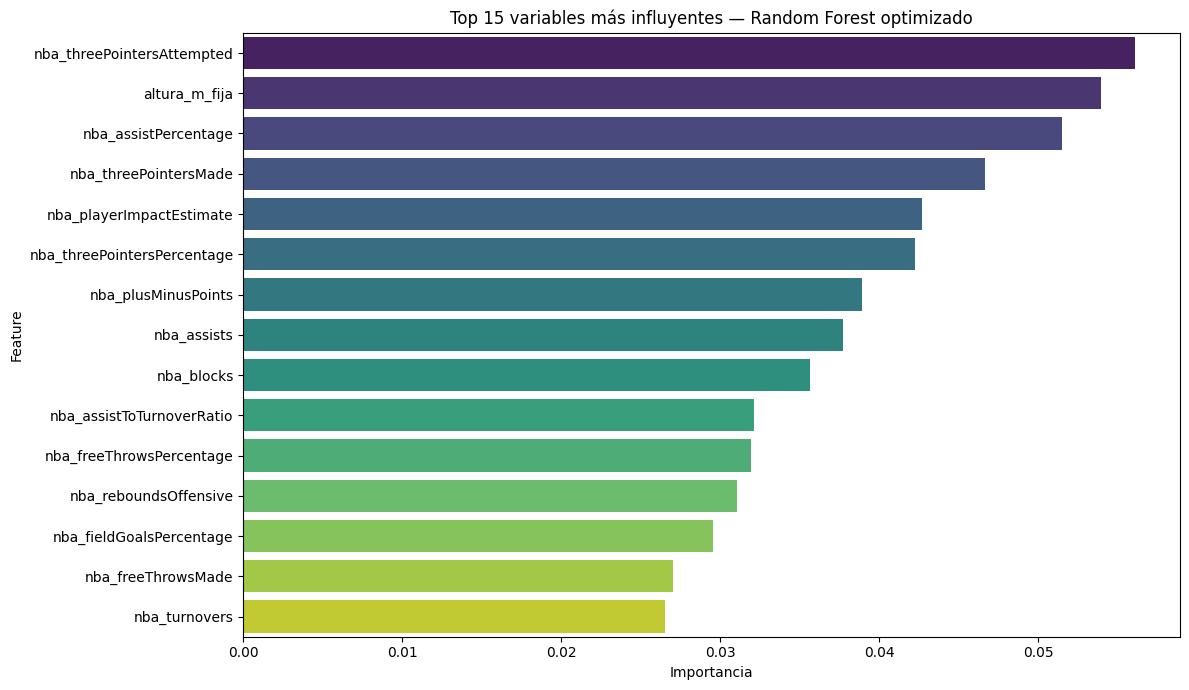


Top 10 variables más importantes:
                    Feature  Importancia
 nba_threePointersAttempted     0.056123
              altura_m_fija     0.053952
       nba_assistPercentage     0.051492
      nba_threePointersMade     0.046668
   nba_playerImpactEstimate     0.042718
nba_threePointersPercentage     0.042274
        nba_plusMinusPoints     0.038902
                nba_assists     0.037753
                 nba_blocks     0.035639
  nba_assistToTurnoverRatio     0.032153


In [171]:
importancias = np.mean(
    [est.feature_importances_ for est in modelo_final.estimators_], axis=0
)
df_importancia = pd.DataFrame({
    'Feature':     feature_cols,
    'Importancia': importancias
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=df_importancia.head(15),
    x='Importancia', y='Feature', palette='viridis'
)
plt.title('Top 15 variables más influyentes — Random Forest optimizado')
plt.tight_layout()
plt.savefig('importancia_variables.png', dpi=150)
plt.show()

print("\nTop 10 variables más importantes:")
print(df_importancia.head(10).to_string(index=False))

In [172]:
# VISUALIZACIÓN DE RESULTADOS.

In [174]:
# Podemos ver en la gráfica o en la tabla los resultados en cada variable, en la gran mayoría son buenos.

                            Estadística       R²        MAE
        Tiros de 3 puntos intentados_pg 0.859405   0.482605
          Tiros de 3 puntos anotados_pg 0.848518   0.203034
             Tiros de 3 puntos anotados 0.810137   7.096003
           Tiros de 3 puntos intentados 0.809538  18.204242
                   Total asistencias_pg 0.790294   0.394978
                      Total asistencias 0.739640  13.845911
         Número de rebotes ofensivos_pg 0.723666   0.233266
                  Tiros libres anotados 0.692684  17.550115
Porcentaje de acierto tiros de 3 puntos 0.677897   7.242546
                Tiros libres intentados 0.665172  22.951253
               Tiros libres anotados_pg 0.641706   0.523859
             Tiros libres intentados_pg 0.622775   0.659752
        Número de tapones realizados_pg 0.621460   0.140879
                           Total puntos 0.621296  83.032091
                       Total rebotes_pg 0.619507   0.751388
            Número de rebotes ofensivos 

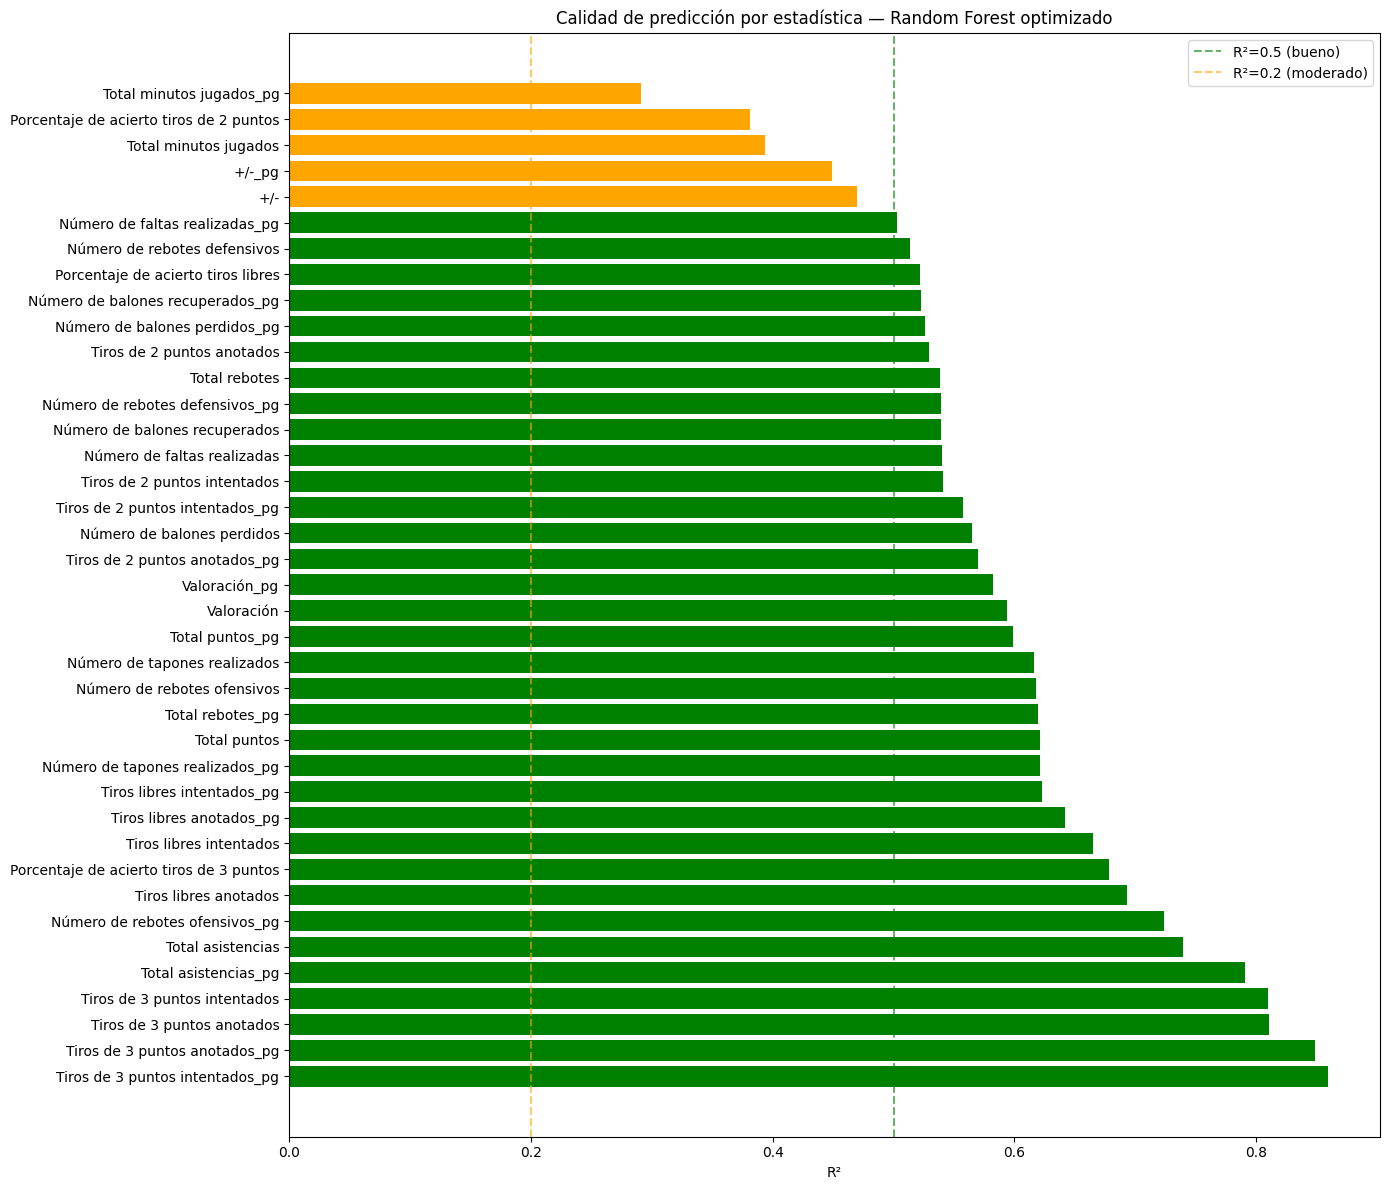

In [173]:
Y_pred_final = modelo_final.predict(X)

registros = []
for i, target in enumerate(all_targets):
    mask = ~np.isnan(Y[:, i])
    if mask.sum() > 1:
        r2  = r2_score(Y[mask, i], Y_pred_final[mask, i])
        mae = mean_absolute_error(Y[mask, i], Y_pred_final[mask, i])
    else:
        r2, mae = np.nan, np.nan
    registros.append({'Estadística': target, 'R²': r2, 'MAE': mae})

df_metricas = pd.DataFrame(registros).sort_values('R²', ascending=False)
print(df_metricas.to_string(index=False))

colores = [
    'green'  if r >= 0.5 else
    'orange' if r >= 0.2 else
    'red'
    for r in df_metricas['R²'].fillna(0)
]

plt.figure(figsize=(14, 12))
plt.barh(df_metricas['Estadística'], df_metricas['R²'], color=colores)
plt.axvline(0.5, color='green',  linestyle='--', alpha=0.6, label='R²=0.5 (bueno)')
plt.axvline(0.2, color='orange', linestyle='--', alpha=0.6, label='R²=0.2 (moderado)')
plt.xlabel('R²')
plt.title('Calidad de predicción por estadística — Random Forest optimizado')
plt.legend()
plt.tight_layout()
plt.savefig('r2_por_estadistica.png', dpi=150)
plt.show()

In [175]:
# Con el modelo ya terminado es hora de guardarlo.

In [179]:
joblib.dump({
    'modelo_final':  modelo_final,
    'usar_scaler':   usar_scaler,
    'scaler':        scaler,
    'feature_cols':  feature_cols,
    'nba_feature_cols': nba_feature_cols,
    'all_targets':   all_targets,
    'le_nba':        le_nba,
    'le_acb':        le_acb
}, 'modelo_predicción_rendimiento_nba->acb.pkl')

print(" Modelo guardado como 'modelo_predicción_rendimiento_nba->acb.pkl'")

 Modelo guardado como 'modelo_predicción_rendimiento_nba->acb.pkl'


In [180]:
# Guardamos el modelo junto a todo lo demás pues para cargarlo más adelante necesitaremos
# los encoders así como el scaler y el mismo orden de columnas con el que se creo el modelo.

In [183]:
# CREACIÓN DE LA FUNCIÓN FINAL

In [184]:
# Función que predice el rendimiento más un ejemplo para comprobar que todo funciona bien.

In [185]:
def predecir_jugador_nba(
    stats_nba_dict: dict,
    posicion_nba: str,
    altura_metros: float,
    posicion_acb: str = 'Alero'
) -> pd.DataFrame:
    """
    Predice las estadísticas ACB de un jugador proveniente de la NBA.

    Parámetros.
    ----------
    stats_nba_dict : dict
        Estadísticas medias del jugador en la NBA.
        Si una estadística no se proporciona, se usa la media del dataset.
    posicion_nba : str
        Posición en NBA → 'G' (Guard), 'F' (Forward), 'C' (Center).
    altura_metros : float
        Altura en metros (ej: 2.01).
    posicion_acb : str
        Posición esperada en ACB → 'Base', 'Escolta', 'Alero', 'Ala-pívot', 'Pívot'.

    Devuelve.
    -------
    DataFrame con promedios por partido y porcentajes predichos para la ACB.
    """

    fila = {}

    for col in nba_feature_cols:
        stat = col.replace('nba_', '')
        fila[col] = stats_nba_dict.get(stat, df_modelo[col].mean())

    try:
        fila['posicion_nba_enc'] = le_nba.transform([posicion_nba])[0]
    except ValueError:
        print(f" Posición NBA '{posicion_nba}' no reconocida. Usando 'F' por defecto.")
        fila['posicion_nba_enc'] = le_nba.transform(['F'])[0]

    fila['altura_m_fija'] = altura_metros

    try:
        fila['posicion_acb_enc'] = le_acb.transform([posicion_acb])[0]
    except ValueError:
        print(f" Posición ACB '{posicion_acb}' no reconocida. Usando 'Alero' por defecto.")
        fila['posicion_acb_enc'] = le_acb.transform(['Alero'])[0]

    X_nuevo = np.array([[fila[c] for c in feature_cols]])

    if usar_scaler:
        X_nuevo = scaler.transform(X_nuevo)

    prediccion = modelo_final.predict(X_nuevo)[0]

    # Filtrar solo promedios por partido y porcentajes, pues son más útiles que ver totales.
    targets_mostrar = [t for t in all_targets if t.endswith('_pg') or t in cols_porcentaje]
    idx_mostrar     = [all_targets.index(t) for t in targets_mostrar]
    nombres_limpios = [t.replace('_pg', '') for t in targets_mostrar]

    return pd.DataFrame({
        'Estadística ACB':         nombres_limpios,
        'Predicción (por partido)': [round(prediccion[i], 2) for i in idx_mostrar]
    })

In [186]:
stats_jugador = {
    'points':                       14.5,
    'assists':                       3.2,
    'reboundsTotal':                 5.8,
    'reboundsOffensive':             1.1,
    'reboundsDefensive':             4.7,
    'fieldGoalsMade':                5.5,
    'fieldGoalsAttempted':          12.0,
    'fieldGoalsPercentage':          0.458,
    'threePointersMade':             1.8,
    'threePointersAttempted':        4.5,
    'threePointersPercentage':       0.380,
    'freeThrowsMade':                1.7,
    'freeThrowsAttempted':           2.1,
    'freeThrowsPercentage':          0.810,
    'steals':                        0.9,
    'blocks':                        0.4,
    'turnovers':                     1.8,
    'foulsPersonal':                 2.2,
    'plusMinusPoints':               2.1,
    'minutos':                      28.0,
    'trueShootingPercentage':        0.545,
    'effectiveFieldGoalPercentage':  0.498,
    'usagePercentage':               0.195,
    'assistPercentage':              0.180,
    'offensiveReboundPercentage':    0.070,
    'defensiveReboundPercentage':    0.190,
    'playerImpactEstimate':          8.2,
    'assistToTurnoverRatio':         1.8,
    'offensiveRating':             112.0,
    'defensiveRating':             110.0,
    'netRating':                     2.0
}

resultado = predecir_jugador_nba(
    stats_nba_dict = stats_jugador,
    posicion_nba   = 'F',
    altura_metros  = 2.03,
    posicion_acb   = 'Alero'
)

print(resultado.to_string(index=False))

                        Estadística ACB  Predicción (por partido)
                           Total puntos                     10.89
                          Total rebotes                      3.08
                      Total asistencias                      2.12
            Número de rebotes ofensivos                      0.70
           Número de rebotes defensivos                      2.24
             Tiros de 3 puntos anotados                      1.09
           Tiros de 3 puntos intentados                      2.74
             Tiros de 2 puntos anotados                      2.60
           Tiros de 2 puntos intentados                      5.01
                  Tiros libres anotados                      2.53
                Tiros libres intentados                      2.85
             Número de balones perdidos                      0.69
          Número de balones recuperados                      1.70
           Número de tapones realizados                      0.25
          

In [190]:
# Abajo se encuentra lo necesario para que cualquier persona pueda utilizar el modelo,
# el archivo que contiene el modelo y se debe mandar y subir a la carpeta del Google
# Collab y la carga y ejecución del modelo, para usarlo solo hay que cambiar las estadísticas
# que vienen puestas como ejemplo por las del jugador.

In [188]:
files.download('modelo_predicción_rendimiento_nba->acb.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [189]:
import joblib
import numpy as np
import pandas as pd

# Cargar el modelo
datos        = joblib.load('modelo_nba_acb.pkl')
modelo_final     = datos['modelo_final']
usar_scaler      = datos['usar_scaler']
scaler           = datos['scaler']
feature_cols     = datos['feature_cols']
nba_feature_cols = datos['nba_feature_cols']
all_targets      = datos['all_targets']
le_nba           = datos['le_nba']
le_acb           = datos['le_acb']

cols_porcentaje = [
    'Porcentaje de acierto tiros de 3 puntos',
    'Porcentaje de acierto tiros de 2 puntos',
    'Porcentaje de acierto tiros libres'
]

# Función de predicción
def predecir_jugador_nba(
    stats_nba_dict: dict,
    posicion_nba: str,
    altura_metros: float,
    posicion_acb: str = 'Alero'
) -> pd.DataFrame:
    """
    Predice las estadísticas ACB de un jugador proveniente de la NBA.

    Parámetros.
    ----------
    stats_nba_dict : dict
        Estadísticas medias del jugador en la NBA sin el prefijo 'nba_'.
    posicion_nba : str
        Posición en NBA → 'G' (Guard), 'F' (Forward), 'C' (Center).
    altura_metros : float
        Altura en metros (ej: 2.01).
    posicion_acb : str
        Posición esperada en ACB → 'Base', 'Escolta', 'Alero', 'Ala-pívot', 'Pívot'.
    """

    fila = {}

    for col in nba_feature_cols:
        stat = col.replace('nba_', '')
        fila[col] = stats_nba_dict.get(stat, 0)

    try:
        fila['posicion_nba_enc'] = le_nba.transform([posicion_nba])[0]
    except ValueError:
        print(f" Posición NBA '{posicion_nba}' no reconocida. Usando 'F' por defecto.")
        fila['posicion_nba_enc'] = le_nba.transform(['F'])[0]

    fila['altura_m_fija'] = altura_metros

    try:
        fila['posicion_acb_enc'] = le_acb.transform([posicion_acb])[0]
    except ValueError:
        print(f" Posición ACB '{posicion_acb}' no reconocida. Usando 'Alero' por defecto.")
        fila['posicion_acb_enc'] = le_acb.transform(['Alero'])[0]

    X_nuevo = np.array([[fila[c] for c in feature_cols]])

    if usar_scaler:
        X_nuevo = scaler.transform(X_nuevo)

    prediccion = modelo_final.predict(X_nuevo)[0]

    targets_mostrar = [t for t in all_targets if t.endswith('_pg') or t in cols_porcentaje]
    idx_mostrar     = [all_targets.index(t) for t in targets_mostrar]
    nombres_limpios = [t.replace('_pg', '') for t in targets_mostrar]

    return pd.DataFrame({
        'Estadística ACB':          nombres_limpios,
        'Predicción (por partido)': [round(prediccion[i], 2) for i in idx_mostrar]
    })



stats_jugador = {
    'points':                       14.5,
    'assists':                       3.2,
    'reboundsTotal':                 5.8,
    'reboundsOffensive':             1.1,
    'reboundsDefensive':             4.7,
    'fieldGoalsMade':                5.5,
    'fieldGoalsAttempted':          12.0,
    'fieldGoalsPercentage':          0.458,
    'threePointersMade':             1.8,
    'threePointersAttempted':        4.5,
    'threePointersPercentage':       0.380,
    'freeThrowsMade':                1.7,
    'freeThrowsAttempted':           2.1,
    'freeThrowsPercentage':          0.810,
    'steals':                        0.9,
    'blocks':                        0.4,
    'turnovers':                     1.8,
    'foulsPersonal':                 2.2,
    'plusMinusPoints':               2.1,
    'minutos':                      28.0,
    'trueShootingPercentage':        0.545,
    'effectiveFieldGoalPercentage':  0.498,
    'usagePercentage':               0.195,
    'assistPercentage':              0.180,
    'offensiveReboundPercentage':    0.070,
    'defensiveReboundPercentage':    0.190,
    'playerImpactEstimate':          8.2,
    'assistToTurnoverRatio':         1.8,
    'offensiveRating':             112.0,
    'defensiveRating':             110.0,
    'netRating':                     2.0
}

resultado = predecir_jugador_nba(
    stats_nba_dict = stats_jugador,
    posicion_nba   = 'F',
    altura_metros  = 2.03,
    posicion_acb   = 'Alero'
)

print(resultado.to_string(index=False))

                        Estadística ACB  Predicción (por partido)
                           Total puntos                     10.89
                          Total rebotes                      3.08
                      Total asistencias                      2.12
            Número de rebotes ofensivos                      0.70
           Número de rebotes defensivos                      2.24
             Tiros de 3 puntos anotados                      1.09
           Tiros de 3 puntos intentados                      2.74
             Tiros de 2 puntos anotados                      2.60
           Tiros de 2 puntos intentados                      5.01
                  Tiros libres anotados                      2.53
                Tiros libres intentados                      2.85
             Número de balones perdidos                      0.69
          Número de balones recuperados                      1.70
           Número de tapones realizados                      0.25
          